# 第 7 章 · 梯度下降与感知机代码实验

[章节网页](../ch7.html)

## 运行内容

- 记录 SGD 损失下降
- 记录感知机参数变化
- 比较不同分类阈值

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import subprocess
import sys
import warnings
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.linear_model import Perceptron, SGDRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, precision_recall_fscore_support
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# 准备线性回归数据：学习时长预测测验分。
gd_df = pd.DataFrame(
    {
        "学习时长": [1, 2, 3, 4, 5, 6, 7, 8],
        "测验分": [52, 55, 61, 66, 70, 76, 82, 86],
    }
)
X_gd = gd_df[["学习时长"]].to_numpy()
y_gd = gd_df["测验分"].to_numpy()
display(gd_df)

,学习时长,测验分
0,1,52
1,2,55
2,3,61
3,4,66
4,5,70
5,6,76
6,7,82
7,8,86


## 1. SGDRegressor

In [3]:
# 用 sklearn SGDRegressor 逐轮更新，记录损失下降过程。
regressor = SGDRegressor(
    loss="squared_error",
    penalty=None,
    learning_rate="constant",
    eta0=0.002,
    random_state=0,
)

gd_rows = []
for epoch in range(1, 31):
    regressor.partial_fit(X_gd, y_gd)
    pred = regressor.predict(X_gd)
    gd_rows.append({
        "轮次": epoch,
        "斜率": round(regressor.coef_[0], 4),
        "截距": round(regressor.intercept_[0], 4),
        "MSE": round(mean_squared_error(y_gd, pred), 3),
    })

gd_trace = pd.DataFrame(gd_rows)
display(gd_trace.tail(8))

,轮次,斜率,截距,MSE
22,23,12.0117,5.4008,338.698
23,24,11.9894,5.5316,336.514
24,25,11.9670,5.6620,334.346
25,26,11.9447,5.7919,332.192
26,27,11.9224,5.9214,330.052
27,28,11.9001,6.0505,327.927
28,29,11.8780,6.1792,325.815
29,30,11.8559,6.3075,323.716


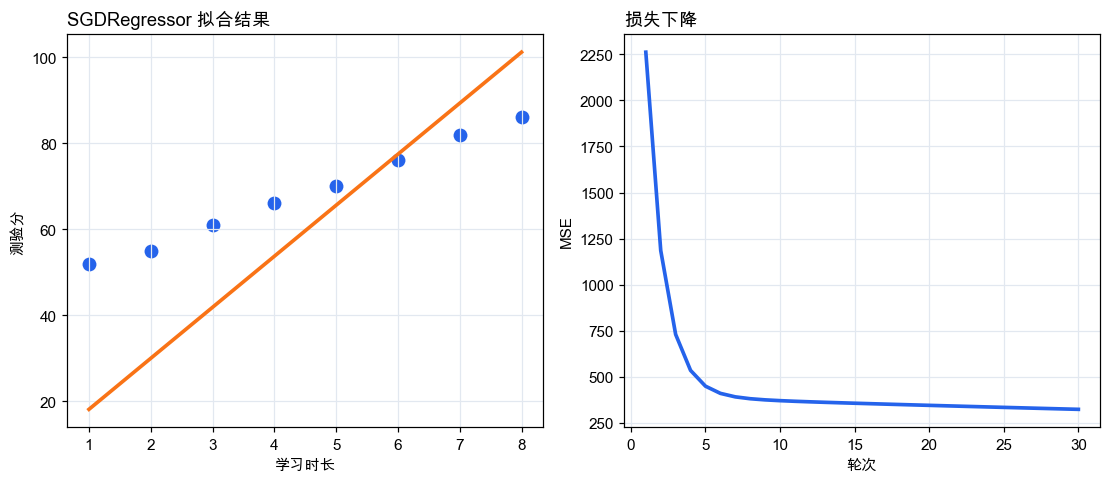

In [4]:
# 绘制拟合直线和 MSE 曲线。
fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.5))

x_line = np.linspace(X_gd.min(), X_gd.max(), 100).reshape(-1, 1)
axes[0].scatter(X_gd[:, 0], y_gd, s=110, color="#2563eb", edgecolor="white", linewidth=1.4)
axes[0].plot(x_line[:, 0], regressor.predict(x_line), color="#f97316", linewidth=2.4)
axes[0].set_title("SGDRegressor 拟合结果", loc="left", fontweight="bold")
axes[0].set_xlabel("学习时长")
axes[0].set_ylabel("测验分")
axes[0].grid(True, color="#e2e8f0", linewidth=0.8)

axes[1].plot(gd_trace["轮次"], gd_trace["MSE"], color="#2563eb", linewidth=2.4)
axes[1].set_title("损失下降", loc="left", fontweight="bold")
axes[1].set_xlabel("轮次")
axes[1].set_ylabel("MSE")
axes[1].grid(True, color="#e2e8f0", linewidth=0.8)

plt.tight_layout()
plt.show()

## 2. Perceptron

In [5]:
# 准备二分类点：两个特征对应一个掌握/未掌握标签。
perceptron_df = pd.DataFrame(
    {
        "正确率": [0.90, 0.82, 0.78, 0.70, 0.58, 0.52, 0.46, 0.40],
        "复盘次数": [3, 3, 2, 2, 1, 1, 0, 0],
        "掌握": [1, 1, 1, 1, 0, 0, 0, 0],
    }
)
X_per = perceptron_df[["正确率", "复盘次数"]].to_numpy()
y_per = perceptron_df["掌握"].to_numpy()
display(perceptron_df)

,正确率,复盘次数,掌握
0,0.90,3,1
1,0.82,3,1
2,0.78,2,1
3,0.70,2,1
4,0.58,1,0
5,0.52,1,0
6,0.46,0,0
7,0.40,0,0


In [6]:
# 用 sklearn Perceptron 的 partial_fit 逐轮学习，记录边界参数。
perceptron = Perceptron(eta0=0.2, random_state=1, warm_start=True)
classes = np.array([0, 1])
per_rows = []

for epoch in range(1, 9):
    perceptron.partial_fit(X_per, y_per, classes=classes)
    pred = perceptron.predict(X_per)
    per_rows.append({
        "轮次": epoch,
        "w_正确率": round(perceptron.coef_[0, 0], 4),
        "w_复盘次数": round(perceptron.coef_[0, 1], 4),
        "bias": round(perceptron.intercept_[0], 4),
        "错误数": int((pred != y_per).sum()),
    })

per_trace = pd.DataFrame(per_rows)
display(per_trace)

,轮次,w_正确率,w_复盘次数,bias,错误数
0,1,-0.032,0.4,-0.2,2
1,2,-0.096,0.4,-0.4,0
2,3,-0.096,0.4,-0.4,0
3,4,-0.096,0.4,-0.4,0
4,5,-0.096,0.4,-0.4,0
5,6,-0.096,0.4,-0.4,0
6,7,-0.096,0.4,-0.4,0
7,8,-0.096,0.4,-0.4,0


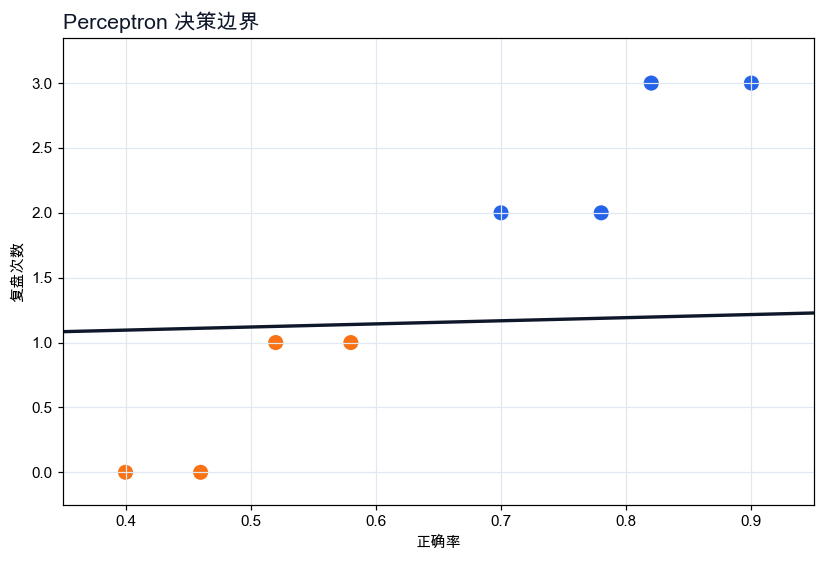

In [7]:
# 绘制感知机决策边界。
fig, ax = plt.subplots(figsize=(7.6, 5.2))
colors = np.where(y_per == 1, "#2563eb", "#f97316")
ax.scatter(X_per[:, 0], X_per[:, 1], c=colors, s=130, edgecolors="white", linewidth=1.5)

x_min, x_max = X_per[:, 0].min() - 0.05, X_per[:, 0].max() + 0.05
x_line = np.linspace(x_min, x_max, 100)
w0, w1 = perceptron.coef_[0]
bias = perceptron.intercept_[0]
y_line = -(w0 * x_line + bias) / w1
ax.plot(x_line, y_line, color="#0f172a", linewidth=2.2)

ax.set_title("Perceptron 决策边界", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_xlabel("正确率")
ax.set_ylabel("复盘次数")
ax.set_xlim(x_min, x_max)
ax.set_ylim(-0.25, 3.35)
ax.grid(True, color="#e2e8f0", linewidth=0.8)
plt.tight_layout()
plt.show()

## 3. 阈值指标

In [8]:
# 同一组概率在不同阈值下会产生不同的 precision / recall。
y_true = np.array([1, 1, 1, 0, 0, 0])
y_score = np.array([0.91, 0.74, 0.62, 0.55, 0.37, 0.21])

metric_rows = []
for threshold in [0.3, 0.5, 0.7]:
    y_hat = (y_score >= threshold).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_hat, average="binary", zero_division=0
    )
    metric_rows.append({
        "阈值": threshold,
        "预测为正": int(y_hat.sum()),
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "F1": round(f1, 3),
    })

display(pd.DataFrame(metric_rows))

,阈值,预测为正,precision,recall,F1
0,0.3,5,0.60,1.000,0.750
1,0.5,4,0.75,1.000,0.857
2,0.7,2,1.00,0.667,0.800
